# Processo Seletivo Analytica 2026 - **Grupo L**

# Requisitos
- Identificar linhas de ônibus “deficientes” em horário de pico
- Propor otimizações dessas linhas via remanejamento da frota
- Identificar critérios de remanejamento.
- EXTRA: Cruzar dados das “piores linhas” com os bairros, buscando os bairros mais afetados
- EXTRA: Adicionar dados no modelo preditivo: mm de chuva nas últimas 2/3 horas e o esperado para próxima hora quando o ônibus sair do terminal (fontes: https://datariov2-pcrj.hub.arcgis.com/datasets/25eceb6bd2214fbb8514e9cdf8e1f0f0_1/explore


# Preparação de dados

Para esse problema, realizamos uma busca dentre diversos datasets e encontramos os seguintes dados disponíveis. Abaixo, mostrarei uma visualização de algumas tabelas de dados.

**Fonte extra de dados**: https://www.data.rio/documents/transporte-rodovi%C3%A1rio-viagens-dos-%C3%B4nibus-identificadas-por-gps/about e https://github.com/prefeitura-rio/queries-rj-smtr/tree/master/models/projeto_subsidio_sppo

# **OBS**:
Para visualizar outras tabelas csv nos códigos abaixo, basta substituir a string dentro de `caminho_dado` pelo caminho do arquivo que se deseja visualizar. Todos os arquivos utilizados estão na pasta `/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL`. Assim que tiver o e-mail de vocês, eu compartilho ela no drive.

## SMTR — Sistema Municipal de Transportes

Dados operacionais, financeiros e estruturais do sistema de transporte público do Rio de Janeiro. Filtrei alguns dados e, abaixo, segue a visualização de alguns que se mostraram mais relevantes para atender os requisitos.

### dashboard_bilhetagem_implantacao_jae
Monitoramento GPS Descrição: Dados agregados de localização de veículos por modal:

- BRT
- Ônibus (SPPO)
- Vans (STPL)
- VLT




In [3]:

import pandas as pd

caminho_dado = "/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/dashboard_bilhetagem_implantacao_jae-20260430T211213Z-3-001/dashboard_bilhetagem_implantacao_jae/gps_agregado_onibus.csv"
df = pd.read_csv(caminho_dado)
display(df.iloc[1000:1250])
print((df['estado_equipamento'] == 'FECHADO').sum())
print(df.shape)
df.info()
df.describe()

,operadora,id_validador,latitude,longitude,data,estado_equipamento,primeiro_datetime_gps,ultimo_datetime_gps,qtde_min_entre_a_prim_e_ultima_transmissao,qtde_min_distintos_houve_transmissao,qtde_registros_gps,qtde_registros_gps_georreferenciados,percentual_registros_gps_georreferenciados,percentual_transmissao_a_cada_min
1000,SANCETUR - SANTA CECILIA TURISMO LTDA,B35T020D00201540,-22.862547,-43.535267,2026-04-26,FECHADO,2026-04-26 00:00:41.353276,2026-04-26 00:04:41.276823,5,5,5,5,1.0,1.0
1001,SANCETUR - SANTA CECILIA TURISMO LTDA,B35T020D00207133,-22.861964,-43.534204,2026-04-26,FECHADO,2026-04-26 00:00:56.947831,2026-04-26 00:04:57.128333,5,5,5,5,1.0,1.0
1002,SANCETUR - SANTA CECILIA TURISMO LTDA,B35T020D00201108,-22.875594,-43.419609,2026-04-26,FECHADO,2026-04-26 00:00:55.363123,2026-04-26 00:04:55.566801,5,5,5,5,1.0,1.0
1003,SANCETUR - SANTA CECILIA TURISMO LTDA,B35T020D00206504,-22.875836,-43.420003,2026-04-26,FECHADO,2026-04-26 00:00:43.229766,2026-04-26 00:04:43.046377,5,5,5,5,1.0,1.0
1004,SANCETUR - SANTA CECILIA TURISMO LTDA,B35T020D00207625,-22.876585,-43.419500,2026-04-26,FECHADO,2026-04-26 00:00:47.126782,2026-04-26 00:04:47.063856,5,5,5,5,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1245,TRANSPORTES FUTURO LTDA,B35T020D00205494,-22.951309,-43.348345,2026-04-26,FECHADO,2026-04-26 00:00:52.336561,2026-04-26 00:04:52.286387,5,5,5,5,1.0,1.0
1246,TRANSPORTES FUTURO LTDA,B35T020D00203417,-22.950718,-43.348123,2026-04-26,FECHADO,2026-04-26 00:00:00.877725,2026-04-26 00:04:00.498694,5,5,5,5,1.0,1.0
1247,TRANSPORTES FUTURO LTDA,B35T020D00205078,-22.949744,-43.348325,2026-04-26,FECHADO,2026-04-26 00:00:07.511207,2026-04-26 00:04:07.662445,5,5,5,5,1.0,1.0
1248,TRANSPORTES FUTURO LTDA,B35T020D00210641,-22.951169,-43.348440,2026-04-26,FECHADO,2026-04-26 00:00:06.135282,2026-04-26 00:04:05.844671,5,5,5,5,1.0,1.0


3057
(3057, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3057 entries, 0 to 3056
Data columns (total 14 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   operadora                                   3057 non-null   object 
 1   id_validador                                3057 non-null   object 
 2   latitude                                    3057 non-null   float64
 3   longitude                                   3057 non-null   float64
 4   data                                        3057 non-null   object 
 5   estado_equipamento                          3057 non-null   object 
 6   primeiro_datetime_gps                       3057 non-null   object 
 7   ultimo_datetime_gps                         3057 non-null   object 
 8   qtde_min_entre_a_prim_e_ultima_transmissao  3057 non-null   int64  
 9   qtde_min_distintos_houve_transmissao        3057 non-null   int64  
 

,latitude,longitude,qtde_min_entre_a_prim_e_ultima_transmissao,qtde_min_distintos_houve_transmissao,qtde_registros_gps,qtde_registros_gps_georreferenciados,percentual_registros_gps_georreferenciados,percentual_transmissao_a_cada_min
count,3057.000000,3057.000000,3057.000000,3057.000000,3057.000000,3057.000000,3057.000000,3057.000000
mean,-22.751618,-43.087552,4.993458,4.989859,4.997383,4.969251,0.994374,0.999182
std,1.752197,3.318828,0.092006,0.126219,0.076702,0.379924,0.074460,0.013693
min,-24.461542,-47.817994,2.000000,2.000000,2.000000,0.000000,0.000000,0.750000
25%,-22.949964,-43.368689,5.000000,5.000000,5.000000,5.000000,1.000000,1.000000
50%,-22.877602,-43.348573,5.000000,5.000000,5.000000,5.000000,1.000000,1.000000
75%,-22.858282,-43.292395,5.000000,5.000000,5.000000,5.000000,1.000000,1.000000
max,0.000000,0.000000,5.000000,5.000000,6.000000,6.000000,1.000000,1.000000


### gtfs
Base padronizada de transporte contendo:
- routes: linhas
- stops: paradas(id das paradas e localização). 485884 linhas
- trips: viagens (onibus, id das rotas e direção) 556360 linhas
- shapes: geometria das rotas (ponto de inicio/fim e formato). 13946 linhas. **aponta para shape**
- calendar + calendar_dates: operação temporal (obras, dias da semana, dia de inicio e término). 923 linhas e 34225 linhas
- ordem_servico: onibus, horarios de funcionamento, tamanho do trajedo ida/volta, total viagens ida/volta (dado o dia da semana) 113629 linhas
- frequencies: contém o intervalo entre um onibus e outro, delimitado pela prefeitura




In [4]:
caminho_dado = "/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/gtfs-20260430T211243Z-3-001/gtfs/frequencies.csv"
df = pd.read_csv(caminho_dado)
display(df.iloc[1:120])
print(df.shape)
df.info()
df.describe()

,feed_version,feed_start_date,feed_end_date,trip_id,start_time,end_time,headway_secs,exact_times,versao_modelo
1,2023-06-01,2023-06-01,2023-06-15,55f4e628-7e93-4183-b766-de2524df1c3b,17:11:00,20:23:00,1440,0,201d79faee763526a030ff998bebea9782efe961
2,2026-02-02,2026-02-02,2026-02-10,ca93c752-a3d8-4ba5-b6b9-a4a92385726c,05:00:00,06:00:00,360,0,f7495a359559836032529b2d93bc4eff1a079265
3,2024-05-15,2024-05-15,2024-06-02,3f6c3eae-c4d8-444c-9838-d0429a28ffd4,07:46:00,08:10:00,720,0,31a6853cb59b7bd67d2f865fa81c6992ac4e1435
4,2025-01-25,2025-01-25,2025-02-09,0310c444-502c-4729-aba9-d055158e9852,17:45:00,18:11:00,1560,0,6f4042d043fc67e3b7822b43f11afe7aab4b22d3
5,2023-12-16,2023-12-16,2023-12-20,42a51dbd-7f02-43f4-8475-bdb0567468ae,13:03:30,13:47:00,435,0,201d79faee763526a030ff998bebea9782efe961
...,...,...,...,...,...,...,...,...,...
115,2024-06-03,2024-06-03,2024-06-04,99d85c09-71e9-40af-9dc6-f326dc118f2c,22:28:00,26:16:00,1140,0,31a6853cb59b7bd67d2f865fa81c6992ac4e1435
116,2026-01-03,2026-01-03,2026-01-18,816a2d43-3606-4720-bca7-f65ec671edc3,06:03:00,06:57:00,1620,0,8df7635a5781e2e43ecc1920667b18f29516caa0
117,2024-12-31,2024-12-31,2025-01-01,a56d1407-71b1-4a99-ba8c-e038b88789a2,15:13:00,15:35:00,1320,0,3e1630ddb15dca783e340faf23f08f68733f4813
118,2023-03-16,2023-03-16,2023-03-31,37edb768-a5a1-44b3-9dc3-b2c9785be9cd,20:51:00,24:27:00,4320,0,201d79faee763526a030ff998bebea9782efe961


(484555, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484555 entries, 0 to 484554
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   feed_version     484555 non-null  object
 1   feed_start_date  484555 non-null  object
 2   feed_end_date    479100 non-null  object
 3   trip_id          484555 non-null  object
 4   start_time       484555 non-null  object
 5   end_time         484555 non-null  object
 6   headway_secs     484555 non-null  int64 
 7   exact_times      484555 non-null  int64 
 8   versao_modelo    484555 non-null  object
dtypes: int64(2), object(7)
memory usage: 33.3+ MB


,headway_secs,exact_times
count,484555.000000,484555.0
mean,1463.111506,0.0
std,1104.580663,0.0
min,60.000000,0.0
25%,600.000000,0.0
50%,1200.000000,0.0
75%,1800.000000,0.0
max,10800.000000,0.0


### br_rj_riodejaneiro_viagem_zirix
**TABELA CENTRAL**

Dados
- Horas de inicio e chegada de cada linha
- **Aponta para o shape id, veículo e número da linha**

Útil para calcular a duração de cada viagem dada a hora, que pode servir para criar um modelo preditivo que alimenta possíveis cálculos de

```
# Isto está formatado como código
```

otimizações.





In [5]:
caminho_dado = "/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/br_rj_riodejaneiro_viagem_zirix-20260430T211251Z-3-001/br_rj_riodejaneiro_viagem_zirix/viagem_informada.csv"
df = pd.read_csv(caminho_dado)
display(df.iloc[250000:251000])
print(df.shape)
df.info()
df.describe()

,data,datetime_partida,datetime_chegada,datetime_processamento,datetime_captura,id_veiculo,trip_id,route_id,shape_id,servico,sentido,id_viagem,versao,datetime_ultima_atualizacao
250000,2026-01-20,2026-01-20 11:00:35,2026-01-20 12:09:09,2026-01-20 12:09:11,2026-01-20 12:20:00,C47460,NaN,O0600AAA0A,v5ag,600,Ida,C47460_600_I_v5ag_20260120110035,c8f981ff13a7041f80169be5b2369842ed133f44,2026-02-25 01:32:42.050288
250001,2026-02-09,2026-02-09 05:38:16,2026-02-09 07:08:46,2026-02-09 07:08:47,2026-02-09 07:20:00,B28576,NaN,O0696AAA0A,68r3,696,Ida,B28576_696_I_68r3_20260209053816,56971229e42ea72637cf282697b64c6dbb6e46b8,2026-02-13 02:32:37.737633
250002,2025-08-14,2025-08-14 21:30:37,2025-08-14 21:59:43,2025-08-14 21:59:44,2025-08-14 22:10:00,A71561,NaN,O0100AAA0A,ffdt,100,Ida,A71561_100_I_ffdt_20250814213037,4044fd38a325410e15a38d1d2c6934da1edca9c7,2025-08-20 01:33:18.142929
250003,2025-03-10,2025-03-10 22:42:34,2025-03-10 23:59:22,2025-03-10 23:59:24,2025-03-11 00:10:00,D86279,NaN,O0853AAA0A,ks4m,853,Volta,D86279_853_V_ks4m_20250310224234,79dec47dac806bca7f59d4b97eabc3692820bb75,2025-03-12 01:34:30.808188
250004,2024-06-10,2024-06-10 02:13:45,2024-06-10 02:45:18,2024-06-10 02:45:19.43,2024-06-10 03:00:00,D17173,NaN,O0885AAA0A,g6hc,885,Ida,583821,21fb978ff4944269e241422bb986837a672c6084,2024-06-27 09:13:26.1124
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
250995,2025-01-24,2025-01-24 17:07:29,2025-01-24 17:55:30,2025-01-24 17:55:34,2025-01-24 18:10:00,D86052,NaN,O0838AAA0A,1032,838,Volta,D86052_838_V_1032_20250124170729,7ce1da121234cacf2ee4801c2433c70ee7f5ecf6,2025-02-11 01:32:45.702863
250996,2025-06-22,2025-06-22 08:13:57,2025-06-22 08:38:45,2025-06-22 08:43:24,2025-06-22 08:50:00,D86208,NaN,O0802AAA0A,O0802AAA0AVDU01,802,Ida,D86208_802_I_O0802AAA0AVDU01_20250622081357,f31b7674c055a63183eaf0a1a103a346ef44601f,2025-06-26 01:32:54.442597
250997,2025-05-19,2025-05-19 04:38:09,2025-05-19 04:58:09,2025-05-19 04:58:09,2025-05-19 05:10:00,D17129,NaN,O0833AAA0A,O0833AAA0AVDU02,833,Volta,D17129_833_V_O0833AAA0AVDU02_20250519043809,cc50861a74f77d8a2a4cc8834cee2365cb35c93b,2025-05-24 01:32:13.123347
250998,2026-02-05,2026-02-05 21:03:54,2026-02-05 22:00:35,2026-02-05 22:00:36,2026-02-05 22:10:00,B25602,NaN,O0606AAV0A,2bl8,SV606,Ida,B25602_SV606_I_2bl8_20260205210354,8df7635a5781e2e43ecc1920667b18f29516caa0,2026-02-10 01:32:29.913426


(256725, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256725 entries, 0 to 256724
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   data                         256725 non-null  object 
 1   datetime_partida             256725 non-null  object 
 2   datetime_chegada             256725 non-null  object 
 3   datetime_processamento       256725 non-null  object 
 4   datetime_captura             256725 non-null  object 
 5   id_veiculo                   256436 non-null  object 
 6   trip_id                      0 non-null       float64
 7   route_id                     255722 non-null  object 
 8   shape_id                     254861 non-null  object 
 9   servico                      256725 non-null  object 
 10  sentido                      256725 non-null  object 
 11  id_viagem                    256725 non-null  object 
 12  versao                       256725 non-null 

,trip_id
count,0.0
mean,NaN
std,NaN
min,NaN
25%,NaN
50%,NaN
75%,NaN
max,NaN


### veiculo
Dados dos veículos do sistema:

- Licenciamento: id de veículo, data da última vistoria, tecnologia, id chassi. 222625 linhas.
- solicitação de licenciamento: solicitações realizadas. Acredito que não está no escopo
- registro agente verao: Acredito que não está no escopo
# - Operação diária
- Inspeções
- Condições operacionais

In [6]:
caminho_dado = "/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/veiculo-20260430T211305Z-3-001/veiculo/sppo_veiculo_dia.csv"
df = pd.read_csv(caminho_dado)
display(df.iloc[1:120])
print(df.shape)
df.info()
df.describe()

,data,id_veiculo,indicadores,status,tecnologia,placa,data_licenciamento,data_infracao,datetime_ultima_atualizacao,versao
1,2024-07-29,A50052,"{""indicador_ar_condicionado"":true,""indicador_a...",Licenciado com ar e não autuado,NaN,NaN,NaN,NaN,2024-07-29 00:00:00,389645e94331a6482e15e038430440ff7db39778
2,2023-06-16,C47893,"{""indicador_ar_condicionado"":true,""indicador_a...",Licenciado com ar e não autuado (023.II),NaN,NaN,NaN,NaN,2023-06-16 00:00:00,NaN
3,2023-03-05,C27106,"{""indicador_ar_condicionado"":true,""indicador_a...",Licenciado com ar e autuado (023.II),NaN,NaN,NaN,NaN,2023-03-05 00:00:00,NaN
4,2023-10-15,D13045,"{""indicador_ar_condicionado"":true,""indicador_a...",Licenciado com ar e não autuado,NaN,NaN,NaN,NaN,2025-07-08 19:52:01.168434,432fd8b43c8d00bd72b10115bcf6649a74371543
5,2023-07-20,B32611,"{""indicador_ar_condicionado"":false,""indicador_...",Licenciado sem ar e não autuado,NaN,NaN,NaN,NaN,2023-07-20 00:00:00,NaN
...,...,...,...,...,...,...,...,...,...,...
115,2024-03-06,C30371,"{""indicador_ar_condicionado"":true,""indicador_a...",Licenciado com ar e não autuado,NaN,NaN,NaN,NaN,2025-07-09 15:19:55.514817,21b44fea9b6195ab051abb2902eb454531b44db2
116,2023-03-11,B28577,"{""indicador_ar_condicionado"":true,""indicador_a...",Licenciado com ar e não autuado (023.II),NaN,NaN,NaN,NaN,2023-03-11 00:00:00,NaN
117,2023-02-14,D86144,"{""indicador_ar_condicionado"":true,""indicador_a...",Licenciado com ar e não autuado (023.II),NaN,NaN,NaN,NaN,2023-02-14 00:00:00,NaN
118,2024-07-10,B32716,"{""indicador_ar_condicionado"":true,""indicador_a...",Licenciado com ar e não autuado,NaN,NaN,NaN,NaN,2024-07-10 00:00:00,7f82815acd73838af72ee1ed091739d16d51b92f


(136939, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136939 entries, 0 to 136938
Data columns (total 10 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   data                         136939 non-null  object
 1   id_veiculo                   136939 non-null  object
 2   indicadores                  136939 non-null  object
 3   status                       136939 non-null  object
 4   tecnologia                   14476 non-null   object
 5   placa                        14476 non-null   object
 6   data_licenciamento           15558 non-null   object
 7   data_infracao                15558 non-null   object
 8   datetime_ultima_atualizacao  136939 non-null  object
 9   versao                       105402 non-null  object
dtypes: object(10)
memory usage: 10.4+ MB


,data,id_veiculo,indicadores,status,tecnologia,placa,data_licenciamento,data_infracao,datetime_ultima_atualizacao,versao
count,136939,136939,136939,136939,14476,14476,15558,15558,136939,105402
unique,806,5225,52,12,4,3829,64,63,596,65
top,2024-10-09,D13122,"{""indicador_ar_condicionado"":true,""indicador_a...",Licenciado com ar e não autuado,BASICO,KXS6356,2025-01-13,2025-01-13,2025-07-08 19:52:01.168434,432fd8b43c8d00bd72b10115bcf6649a74371543
freq,219,53,56347,85646,10639,13,1324,1108,20751,20751


# Solução proposta

Com base nos dados acima, iremos analisar os dados para aplicar otimizações na quantidade de veículos por linha de ônibus. O objetivo é diminuir o tempo de espera dos passageiros por linha de ônibus.

Utilizaremos o o intervalo `headway_secs` de início de linha delimitado pela prefeitura na tabela `frequencies.csv` do `gtfs` e, com ele, definiremos que o intervalo médio de espera em um ponto é `headway_secs`/2

(Necessário embasar essa conta acima, sei que ela vem de probabilidade se a gente considerar que ass pessoas chegam nos pontos de forma uniforme e aleatória.)

Em adição, criaremos um modelo preditivo que receberá o tempo de viagem descrito na tabela `viagem_informada.csv` do dataset `br_rj_riodejaneiro_viagem_zirix`, em adição da linha, sentido, horário e dia da semana. O modelo deverá ser  capaz de prever a duração da viagem em qualquer horário e dia futuro.

(Ainda não sei se uma regressão polinomial para cada uma das linhas vai servir para descrever esse tempo de deslocamento dado a hora e dia)

Uniremos os dados de tempo de viagem e intervalo médio nos pontos e, com isso, calcularemos a quantidade de ônibus necessários que essa linha deve possuir naquele momento para cumprir o intervalo médio.

Podemos realizar uma análise dos dados fornecidos e indicar o atraso médio por linha e informações similares, demonstrando a necessidade da nossa aplicação.

Se sobrar tempo, podemos melhorar o modelo para realocar ônibus entre as linhas de forma dinâmica durante o dia, para servir de apoio a secretaria de transportes e empresas de ônibus.

(falta adicionar um tempo de repouso na conta)
(falta embasar esse problema - má distribuição de frota de onibus rj)

## Limitações
Para um primeiro momento, vou considerar que o tempo de deslocamento entre os pontos de ônibus é constante e uniforme. Sei que é uma suposição que foge da realidade do problema, mas, se mostra necessária por conta do trabalho computacional na coleta, tratamento e análise exploratória de milhões de linhas de dados de GPS de ônibus, que devem ser cruzados com a localização das paradas para calcular o deslocamento entre um ponto e outro.

Além disso, com os dados de GPS, seria possível otimizar o modelo para estimar o deslocamento entre trechos da rota com todas as linhas que cruzam esses trechos, sem se limitar a uma análise que considera apenas os ônibus da mesma linha.

Com essa análise por trecho, seria possível aprimorar o modelo para evitar o efeito sanfona (quando os ônibus colam um atrás do outro e chegam juntos no mesmo ponto)





#Dados necessários para o modelo preditivo

1. frequencies.csv (GTFS)
	1. start_time e end_time. Dados sobre hora do dia que a regra abaixo deve valer
	2. headway_secs . Tempo que um ônibus leva para chegar no mesmo ponto que um ônibus acabou de passar (usado para conta de ônibus em linha)
	3. trip_id. Id da viagem. Identifica o dado com a viagem
2. trips.csv(GTFS)
	1. trips_id. Utilizado para dar merge com a tabela acima
	2. trip_short_name: Nome da linha (ex: 324)
	3. direction_id: Direção ida ou volta.
3. viagem_informada.csv (br_rj_riodejaneiro_viagem_zirix-20260430T211251Z-3-001/br_rj_riodejaneiro_viagem_zirix)
	1. servico: será usada para cruzar com trip_short)name da tabela acima
	2. sentido: Teremos que levar em consideração a Ida e Volta da linha, para cruzar com 0 ou 1 do direction_id da tabela acima. No caso, Ida = 0 e Volta = 1
	3. datetime_partida e datetime_chegada: Usados para calcular o tempo de duração de uma viagem de ônibus

O objetivo é juntar todos os dados acima em uma única tabela, para facilitar a manipulação de dados. Porém, antes de uni-las, é importante tratar valores nulos, inválidos e outliers. Segue abaixo o algoritmo que busca por essas situações.

In [7]:
import matplotlib.pyplot as plt

caminho_frequencies = "/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/gtfs-20260430T211243Z-3-001/gtfs/frequencies.csv"
caminho_trips = "/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/gtfs-20260430T211243Z-3-001/gtfs/trips.csv"
caminho_viagem = "/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/br_rj_riodejaneiro_viagem_zirix-20260430T211251Z-3-001/br_rj_riodejaneiro_viagem_zirix/viagem_informada.csv"

caminhos = [caminho_frequencies, caminho_trips, caminho_viagem]

for caminho in caminhos:
  df = pd.read_csv(caminho)
  display(df.isnull().sum())
  df.info()

,0
feed_version,0
feed_start_date,0
feed_end_date,5455
trip_id,0
start_time,0
end_time,0
headway_secs,0
exact_times,0
versao_modelo,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 484555 entries, 0 to 484554
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   feed_version     484555 non-null  object
 1   feed_start_date  484555 non-null  object
 2   feed_end_date    479100 non-null  object
 3   trip_id          484555 non-null  object
 4   start_time       484555 non-null  object
 5   end_time         484555 non-null  object
 6   headway_secs     484555 non-null  int64 
 7   exact_times      484555 non-null  int64 
 8   versao_modelo    484555 non-null  object
dtypes: int64(2), object(7)
memory usage: 33.3+ MB


,0
feed_version,0
feed_start_date,0
feed_end_date,5907
route_id,0
service_id,0
trip_id,0
trip_headsign,452
trip_short_name,0
direction_id,9
block_id,556360


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 556360 entries, 0 to 556359
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   feed_version           556360 non-null  object 
 1   feed_start_date        556360 non-null  object 
 2   feed_end_date          550453 non-null  object 
 3   route_id               556360 non-null  object 
 4   service_id             556360 non-null  object 
 5   trip_id                556360 non-null  object 
 6   trip_headsign          555908 non-null  object 
 7   trip_short_name        556360 non-null  object 
 8   direction_id           556351 non-null  float64
 9   block_id               0 non-null       float64
 10  shape_id               556359 non-null  object 
 11  wheelchair_accessible  0 non-null       float64
 12  bikes_allowed          0 non-null       float64
 13  versao_modelo          556360 non-null  object 
dtypes: float64(4), object(10)
memory usa

,0
data,0
datetime_partida,0
datetime_chegada,0
datetime_processamento,0
datetime_captura,0
id_veiculo,289
trip_id,256725
route_id,1003
shape_id,1864
servico,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 256725 entries, 0 to 256724
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   data                         256725 non-null  object 
 1   datetime_partida             256725 non-null  object 
 2   datetime_chegada             256725 non-null  object 
 3   datetime_processamento       256725 non-null  object 
 4   datetime_captura             256725 non-null  object 
 5   id_veiculo                   256436 non-null  object 
 6   trip_id                      0 non-null       float64
 7   route_id                     255722 non-null  object 
 8   shape_id                     254861 non-null  object 
 9   servico                      256725 non-null  object 
 10  sentido                      256725 non-null  object 
 11  id_viagem                    256725 non-null  object 
 12  versao                       256725 non-null  object 
 13 

Existem 9 linhas em trips.csv que possuem valores nulos para o sentido da viagem. Abaixo veremos quais linhas são essas:

In [8]:
df = pd.read_csv("/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/gtfs-20260430T211243Z-3-001/gtfs/trips.csv")
display(df[df['direction_id'].isnull()])

,feed_version,feed_start_date,feed_end_date,route_id,service_id,trip_id,trip_headsign,trip_short_name,direction_id,block_id,shape_id,wheelchair_accessible,bikes_allowed,versao_modelo
50608,2023-07-16,2023-07-16,2023-07-31,O0936AAA0A,U_REG,3130cc51-0e07-4acd-a869-9010b20fd8eb,Cidade Unviersitária,936,NaN,NaN,3wry,NaN,NaN,201d79faee763526a030ff998bebea9782efe961
109945,2025-12-21,2025-12-21,2025-12-26,O0298AAE0A,U_REG,200199e4-20ff-4c26-9c5b-34754bd0de2b,Botafogo [alternativo],SE298,NaN,NaN,eeu0,NaN,NaN,22d4617d5bb2889f600112473f926c3a35f27ed9
130142,2025-12-21,2025-12-21,2025-12-26,O0298AAE0A,U_REG,54c5f495-01c2-4f12-9aa0-4e057d49e9eb,Botafogo [reveillon],SE298,NaN,NaN,b4vf,NaN,NaN,22d4617d5bb2889f600112473f926c3a35f27ed9
152990,2025-12-21,2025-12-21,2025-12-26,O0169AAE0A,U_REG,3ce995d2-d187-4e0f-ade5-d1aa4ae75ae3,Botafogo [reveillon],SE169,NaN,NaN,ebjm,NaN,NaN,22d4617d5bb2889f600112473f926c3a35f27ed9
211615,2023-03-01,2023-03-01,2023-03-15,O0601AAP0A,D,29746496-fb8e-4138-bf10-8f86ae189735,Hospital Cardoso Fontes,SP601,NaN,NaN,u8r4,NaN,NaN,201d79faee763526a030ff998bebea9782efe961
391549,2025-12-21,2025-12-21,2025-12-26,O0397AAE0A,U_REG,75be6e22-b5e6-44b5-aef2-d3f171bbbf5d,Botafogo [alternativo],SE397,NaN,NaN,7kqt,NaN,NaN,22d4617d5bb2889f600112473f926c3a35f27ed9
481228,2025-12-21,2025-12-21,2025-12-26,O0169AAE0A,U_REG,9a52e241-b669-422d-92c6-e716d6b21c11,G. Osório [alternativo],SE169,NaN,NaN,fyfp,NaN,NaN,22d4617d5bb2889f600112473f926c3a35f27ed9
499266,2023-07-16,2023-07-16,2023-07-31,O0936AAA0A,U_REG,59fb2087-c4cf-41d2-9897-ceab0c481bdb,Cidade Unviersitária,936,NaN,NaN,3wry,NaN,NaN,201d79faee763526a030ff998bebea9782efe961
514972,2025-12-21,2025-12-21,2025-12-26,O0298AAE0A,U_REG,0ca2a81d-a1a8-41fb-bc11-6c389087ba0a,Castelo [alternativo],SE298,NaN,NaN,e5lu,NaN,NaN,22d4617d5bb2889f600112473f926c3a35f27ed9


São linhas alternativas, algumas para eventos como reveillon. Decidi excluir do dataset

In [9]:
df = pd.read_csv("/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/gtfs-20260430T211243Z-3-001/gtfs/trips.csv")
df_trips_limpo = df.dropna(subset=['direction_id']).reset_index(drop=True) #esse reset index é para atualizar o indice apos a exclusao
caminho_trips_limpo = "/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados tratados/trips_limpo.csv"
df_trips_limpo.to_csv(caminho_trips_limpo, index=False)
df_trips_limpo.isnull().sum()


,0
feed_version,0
feed_start_date,0
feed_end_date,5907
route_id,0
service_id,0
trip_id,0
trip_headsign,452
trip_short_name,0
direction_id,0
block_id,556351


Verificarei abaixo se existem outliers na coluna de `headway_secs` de `frequencies.csv`

<Figure size 640x480 with 0 Axes>

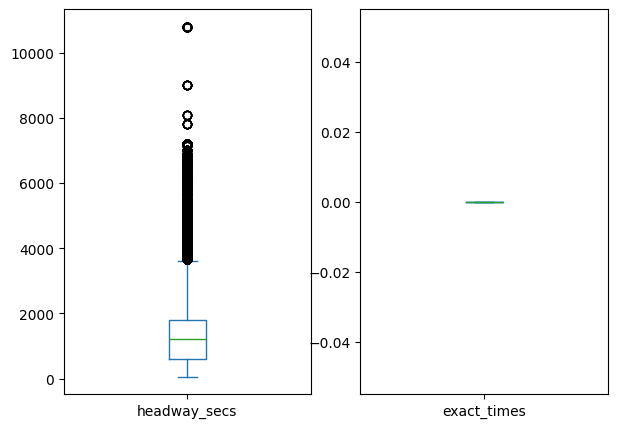

<Figure size 640x480 with 0 Axes>

In [10]:
#necessário converter o headway de string para int primeiro
df = pd.read_csv("/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/gtfs-20260430T211243Z-3-001/gtfs/frequencies.csv")
df_freq_limpo = df
df_freq_limpo['headway_secs'] = df['headway_secs'].astype(int)
caminho_freq_limpo = "/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados tratados/freq_limpo.csv"
df_freq_limpo.to_csv(caminho_freq_limpo, index=False)

df.plot(kind='box', figsize=(30, 5), subplots=True, layout=(1, 8))
plt.figure()



Temos poucos valores distantes próximos a 10.000 segundos. Isso equivale a aproximadamente 3 horas. Provavelmente são ônibus que funcionam de madrugada ou que possuem poucos horários por dia. Não temos outliers que necessitem ser excluídos.

Abaixo, vou incluir a coluna `duracao_viagem` na tabela `viagem_informada.csv`. Em seguida, realizarei a análise buscando por outliers (viagens excessivamente longas ou curtas demais).

In [14]:
#criando cópia na memória
df = pd.read_csv("/content/drive/MyDrive/DadosAnalyticaPS2026-GrupoL/dados brutos/br_rj_riodejaneiro_viagem_zirix-20260430T211251Z-3-001/br_rj_riodejaneiro_viagem_zirix/viagem_informada.csv")
df_viagens_limpo = df.copy()

#convertendo os valores de data, hora, minuto e segundo de string para datetime64
df_viagens_limpo['datetime_chegada'] = pd.to_datetime(df_viagens_limpo['datetime_chegada'])
df_viagens_limpo['datetime_partida'] = pd.to_datetime(df_viagens_limpo['datetime_partida'])

#incluindo a coluna duracao_viagem_minutos nesse dataset
df_viagens_limpo['viagem_minutos'] = (df_viagens_limpo['datetime_chegada'] - df_viagens_limpo['datetime_partida']).dt.total_seconds() / 60

display(df_viagens_limpo.head())



,data,datetime_partida,datetime_chegada,datetime_processamento,datetime_captura,id_veiculo,trip_id,route_id,shape_id,servico,sentido,id_viagem,versao,datetime_ultima_atualizacao,viagem_minutos
0,2026-02-25,2026-02-25 06:01:01,2026-02-25 07:03:31,2026-02-25 07:03:33,2026-02-25 07:10:00,A71544,NaN,O0409AAA0A,gnoq,409,Ida,A71544_409_I_gnoq_20260225060101,26a029cc24759a6b0acbfc87d7999e9b7f78db7c,2026-02-28 01:32:30.297869,62.500000
1,2024-12-08,2024-12-08 18:23:39,2024-12-08 19:34:38,2024-12-08 19:34:40,2024-12-08 19:40:00,B10003,NaN,186,421,901,Ida,B10003_901_I_421_20241208182339,0797b1e917d2ed2d50489a35abd2b87dcab54b55,2024-12-10 01:34:25.331602,70.983333
2,2025-09-19,2025-09-19 06:41:53,2025-09-19 08:27:23,2025-09-19 08:27:25,2025-09-19 08:40:00,D13012,NaN,O0383AAA0A,34402958-de24-498e-b913-3f70f5311747,383,Volta,D13012_383_V_34402958-de24-498e-b913-3f70f5311...,06f003ebcace75a8702b05d063933a3ac6edc0f8,2025-09-26 01:32:16.328995,105.500000
3,2025-06-27,2025-06-27 04:53:31,2025-06-27 05:11:55,2025-06-27 05:11:58,2025-06-27 05:20:00,A48056,NaN,O0202AAA0A,1760,202,Ida,A48056_202_I_1760_20250627045331,477e243683cf4516bd39ad4ee8ff21793b78279c,2025-07-02 01:32:34.960347,18.400000
4,2025-02-19,2025-02-19 07:15:43,2025-02-19 09:27:43,2025-02-19 20:17:14,2025-02-19 20:30:00,C47638,NaN,O0390AAA0A,5au5,390,Ida,C47638_390_I_5au5_20250219071543,8b2a8320de08cc624e12dbbd49f8e02da750444f,2025-02-28 01:34:03.91567,132.000000
